In [31]:
import pandas as pd

df = pd.read_excel("../data/raw/hydrovoltaic_data.xlsx")

df.head()

c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_MΩ,output_timescale_class,stability_time_min,dominant_mechanism,notes
0,10.1038/s41467-025-63549-1,0,2025,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,1,0.0,4.00,NaN,NaN,NaN,seconds,NaN,ion_concentration_gradient,NaN
1,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,NaN
2,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,NaN
3,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,NaN
4,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,NaN


In [32]:
df.shape

(219, 37)

In [33]:
df.columns

Index(['paper_doi', 'review_covered', 'ref_year', 'device_structure',
       'built_in_asymmetry', 'asymmetry_origin', 'primary_mobile_ion',
       'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin',
       'auxiliary_redox_present', 'continuous_output',
       'water_interaction_mode', 'rh_percent', 'inorganic_electrolyte_present',
       'inorganic_electrolyte_type', 'inorganic_electrolyte_concentration_wt%',
       'polyelectrolyte_present', 'polyelectrolyte_anionic',
       'polyelectrolyte_cationic', 'polyelectrolyte_zwitterionic',
       'active_material_raw', 'material_class', 'structure_class',
       'ionic_groups', 'top_electrode', 'bottom_electrode',
       'electrode_symmetry', 'metal_electrode', 'voc_V', 'jsc_uA_cm2',
       'power_density_uW_cm2', 'internal_resistance_MΩ',
       'output_timescale_class', 'stability_time_min', 'dominant_mechanism',
       'notes'],
      dtype='str')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   paper_doi                                219 non-null    str    
 1   review_covered                           219 non-null    int64  
 2   ref_year                                 219 non-null    int64  
 3   device_structure                         219 non-null    str    
 4   built_in_asymmetry                       219 non-null    int64  
 5   asymmetry_origin                         219 non-null    str    
 6   primary_mobile_ion                       219 non-null    str    
 7   secondary_ion_present                    219 non-null    int64  
 8   secondary_mobile_ion                     88 non-null     str    
 9   ion_origin                               219 non-null    str    
 10  auxiliary_redox_present                  219 non-null    int6

In [35]:
df.isnull().sum()

paper_doi                                    0
review_covered                               0
ref_year                                     0
device_structure                             0
built_in_asymmetry                           0
asymmetry_origin                             0
primary_mobile_ion                           0
secondary_ion_present                        0
secondary_mobile_ion                       131
ion_origin                                   0
auxiliary_redox_present                      0
continuous_output                            0
water_interaction_mode                       0
rh_percent                                  42
inorganic_electrolyte_present                0
inorganic_electrolyte_type                 151
inorganic_electrolyte_concentration_wt%    178
polyelectrolyte_present                      0
polyelectrolyte_anionic                    163
polyelectrolyte_cationic                   197
polyelectrolyte_zwitterionic               205
active_materi

In [36]:
df = df.drop(columns=["notes"])

In [37]:
# polyelectrolyte 类型 → binary encoding

df["has_anionic"] = df["polyelectrolyte_anionic"].notnull().astype(int)
df["has_cationic"] = df["polyelectrolyte_cationic"].notnull().astype(int)
df["has_zwitterionic"] = df["polyelectrolyte_zwitterionic"].notnull().astype(int)

In [38]:
df[["has_anionic", "has_cationic", "has_zwitterionic"]].sum()

has_anionic         56
has_cationic        22
has_zwitterionic    14
dtype: int64

In [39]:
# reserve the original columns for later use
df["polyelectrolyte_anionic_raw"] = df["polyelectrolyte_anionic"]
df["polyelectrolyte_cationic_raw"] = df["polyelectrolyte_cationic"]
df["polyelectrolyte_zwitterionic_raw"] = df["polyelectrolyte_zwitterionic"]

In [40]:
df = df.drop(columns=[
    "polyelectrolyte_anionic",
    "polyelectrolyte_cationic",
    "polyelectrolyte_zwitterionic"
])

In [41]:
df["has_any_polyelectrolyte"] = (
    df["has_anionic"] + 
    df["has_cationic"] + 
    df["has_zwitterionic"]
) > 0

df["has_any_polyelectrolyte"] = df["has_any_polyelectrolyte"].astype(int)

In [42]:
df.columns

Index(['paper_doi', 'review_covered', 'ref_year', 'device_structure',
       'built_in_asymmetry', 'asymmetry_origin', 'primary_mobile_ion',
       'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin',
       'auxiliary_redox_present', 'continuous_output',
       'water_interaction_mode', 'rh_percent', 'inorganic_electrolyte_present',
       'inorganic_electrolyte_type', 'inorganic_electrolyte_concentration_wt%',
       'polyelectrolyte_present', 'active_material_raw', 'material_class',
       'structure_class', 'ionic_groups', 'top_electrode', 'bottom_electrode',
       'electrode_symmetry', 'metal_electrode', 'voc_V', 'jsc_uA_cm2',
       'power_density_uW_cm2', 'internal_resistance_MΩ',
       'output_timescale_class', 'stability_time_min', 'dominant_mechanism',
       'has_anionic', 'has_cationic', 'has_zwitterionic',
       'polyelectrolyte_anionic_raw', 'polyelectrolyte_cationic_raw',
       'polyelectrolyte_zwitterionic_raw', 'has_any_polyelectrolyte'],
      dtype='str

In [43]:
df[["voc_V", "jsc_uA_cm2", "power_density_uW_cm2"]].describe()

,voc_V,jsc_uA_cm2,power_density_uW_cm2
count,217.000000,184.000000,131.000000
mean,0.777843,318.777577,45.604374
std,0.852905,2259.061655,227.037319
min,0.012000,0.003000,0.000360
25%,0.300000,0.400000,0.081250
50%,0.600000,4.000000,0.860000
75%,0.880000,22.000000,7.800000
max,5.000000,27700.000000,1860.000000


In [44]:
df.groupby("continuous_output")["jsc_uA_cm2"].describe()

,count,mean,std,min,25%,50%,75%,max
continuous_output,,,,,,,,
0,25.0,1919.759360,5934.891154,0.010,0.400,5.0,25.0,27700.0
1,159.0,67.050881,302.003796,0.003,0.375,4.0,21.9,3000.0


In [45]:
df_clean = df[df["continuous_output"] == 1].copy()

In [46]:
df_clean.shape
df_clean[["voc_V", "jsc_uA_cm2"]].describe()

,voc_V,jsc_uA_cm2
count,183.000000,159.000000
mean,0.821087,67.050881
std,0.833232,302.003796
min,0.019000,0.003000
25%,0.355000,0.375000
50%,0.610000,4.000000
75%,0.925000,21.900000
max,5.000000,3000.000000


In [47]:
features = [
    "material_class",
    "structure_class",
    "device_structure",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "dominant_mechanism",
    "water_interaction_mode",
    "rh_percent"
]

target = "voc_V"

## Model V1

In [48]:
df_model = df_clean[features + [target]].copy()
df_model.shape

(183, 13)

In [49]:
df_model.isnull().sum()

material_class                    0
structure_class                   0
device_structure                  0
built_in_asymmetry                0
inorganic_electrolyte_present     0
polyelectrolyte_present           0
has_anionic                       0
has_cationic                      0
has_zwitterionic                  0
dominant_mechanism                0
water_interaction_mode            0
rh_percent                       37
voc_V                             0
dtype: int64

In [50]:
X = df_model[features]
y = df_model[target]

X_encoded = pd.get_dummies(X, drop_first=False)
X_encoded.head()

,built_in_asymmetry,inorganic_electrolyte_present,polyelectrolyte_present,has_anionic,has_cationic,has_zwitterionic,rh_percent,material_class_MOF/COF,material_class_biomass,material_class_carbon,...,device_structure_sandwich,dominant_mechanism_ion_concentration_gradient,dominant_mechanism_ion_concentration_gradient + pyroelectricity,dominant_mechanism_ion_concentration_gradient + radiative_cooling_enhanced_evaporation,dominant_mechanism_ion_concentration_gradient + schottky_junction,dominant_mechanism_ion_concentration_gradient + thermo_diffusion,dominant_mechanism_streaming,water_interaction_mode_evaporation_driven,water_interaction_mode_liquid_contact,water_interaction_mode_vapor_adsorption
1,0,0,0,0,0,0,60.0,False,False,True,...,False,False,False,False,False,False,True,True,False,False
2,0,0,0,0,0,0,62.0,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,1,0,0,0,0,0,NaN,False,False,False,...,False,False,False,False,False,False,True,True,False,False
4,0,0,0,0,0,0,NaN,False,False,True,...,False,False,False,False,False,False,True,True,False,False
5,0,0,0,0,0,0,55.0,False,False,True,...,False,False,False,False,False,False,True,True,False,False


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((146, 32), (37, 32))

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [53]:
y_pred = rf_model.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -1.3148392554097894
RMSE: 0.808570832286513
MAE: 0.5592762225829722


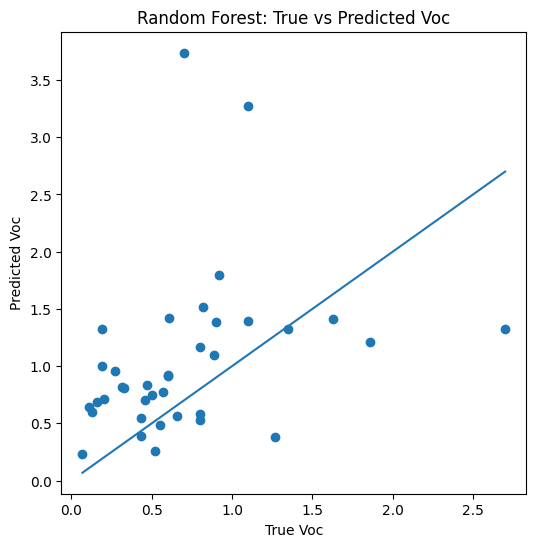

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("True Voc")
plt.ylabel("Predicted Voc")
plt.title("Random Forest: True vs Predicted Voc")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

## Model v1: Baseline Random Forest

A baseline Random Forest model was trained to predict open-circuit voltage (Voc) using a set of high-level descriptors, including material class, structure class, electrolyte presence, and dominant mechanism.

### Feature Set

* Material and structure descriptors: material_class, structure_class, device_structure
* Electrolyte-related features: inorganic_electrolyte_present, polyelectrolyte_present
* Polyelectrolyte type (binary): has_anionic, has_cationic, has_zwitterionic
* Mechanism-related features: dominant_mechanism, water_interaction_mode
* Built-in asymmetry

### Result

* R² < 0 (poor predictive performance)
* The model performs worse than a mean-value baseline

### Interpretation

* High-level categorical descriptors alone are insufficient to explain variations in Voc
* Important structural or compositional information is likely missing
* The current feature set does not adequately capture the underlying physics of hydrovoltaic systems

### Conclusion

A more detailed feature set is required, particularly including finer-grained descriptors such as ionic groups, electrode materials, and structural details.


## Model V2

In [56]:
[col for col in df_clean.columns if any(k in col for k in ["electrode", "ionic", "material", "structure"])]

['device_structure',
 'active_material_raw',
 'material_class',
 'structure_class',
 'ionic_groups',
 'top_electrode',
 'bottom_electrode',
 'electrode_symmetry',
 'metal_electrode',
 'has_anionic',
 'has_cationic',
 'has_zwitterionic',
 'polyelectrolyte_anionic_raw',
 'polyelectrolyte_cationic_raw',
 'polyelectrolyte_zwitterionic_raw']

In [57]:
features_v2 = [
    # Original（reserve）
    "material_class",
    "structure_class",
    "device_structure",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "dominant_mechanism",
    "water_interaction_mode",

    # new（key）
    "ionic_groups",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode"
]

In [58]:
df_model_v2 = df_clean[features_v2 + ["voc_V"]].copy()

df_model_v2.isnull().sum()

material_class                   0
structure_class                  0
device_structure                 0
built_in_asymmetry               0
inorganic_electrolyte_present    0
polyelectrolyte_present          0
has_anionic                      0
has_cationic                     0
has_zwitterionic                 0
dominant_mechanism               0
water_interaction_mode           0
ionic_groups                     0
top_electrode                    0
bottom_electrode                 0
electrode_symmetry               0
metal_electrode                  0
voc_V                            0
dtype: int64

In [59]:
X_v2 = df_model_v2[features_v2]
y_v2 = df_model_v2["voc_V"]

X_v2_encoded = pd.get_dummies(X_v2, drop_first=False)

X_v2_encoded.shape

(183, 114)

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_v2_encoded, y_v2, test_size=0.2, random_state=42
)

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_v2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [62]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = rf_v2.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -0.19718230085498556
RMSE: 0.5814840350031983
MAE: 0.443118306996057


## Model V3

In [63]:
# Count rows with both Voc and Jsc available
df_clean[["voc_V", "jsc_uA_cm2"]].dropna().shape

(159, 2)